# Laboratorul I
## Tema: Utilizarea diferitor algoritmi de clusterizare pe diferite tipuri de date. Vizualizarea datelor.
Efectuat: Perebinos Daniel

### Instalarea dependentelor

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

### 

### Data preprocessing

In [2]:
import pandas as pd

df = pd.read_csv('dataset.csv', index_col=0)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,0
1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,0
2,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,1
3,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,0
4,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   int64  
 2   Dependents        7043 non-null   int64  
 3   tenure            7043 non-null   int64  
 4   PhoneService      7043 non-null   int64  
 5   MultipleLines     7043 non-null   int64  
 6   InternetService   7043 non-null   int64  
 7   OnlineSecurity    7043 non-null   int64  
 8   OnlineBackup      7043 non-null   int64  
 9   DeviceProtection  7043 non-null   int64  
 10  TechSupport       7043 non-null   int64  
 11  StreamingTV       7043 non-null   int64  
 12  StreamingMovies   7043 non-null   int64  
 13  Contract          7043 non-null   int64  
 14  PaperlessBilling  7043 non-null   int64  
 15  PaymentMethod     7043 non-null   int64  
 16  MonthlyCharges    7043 non-null   float64
 17  

In [4]:
df.isna().sum()

SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
Churn               0
dtype: int64

<Axes: >

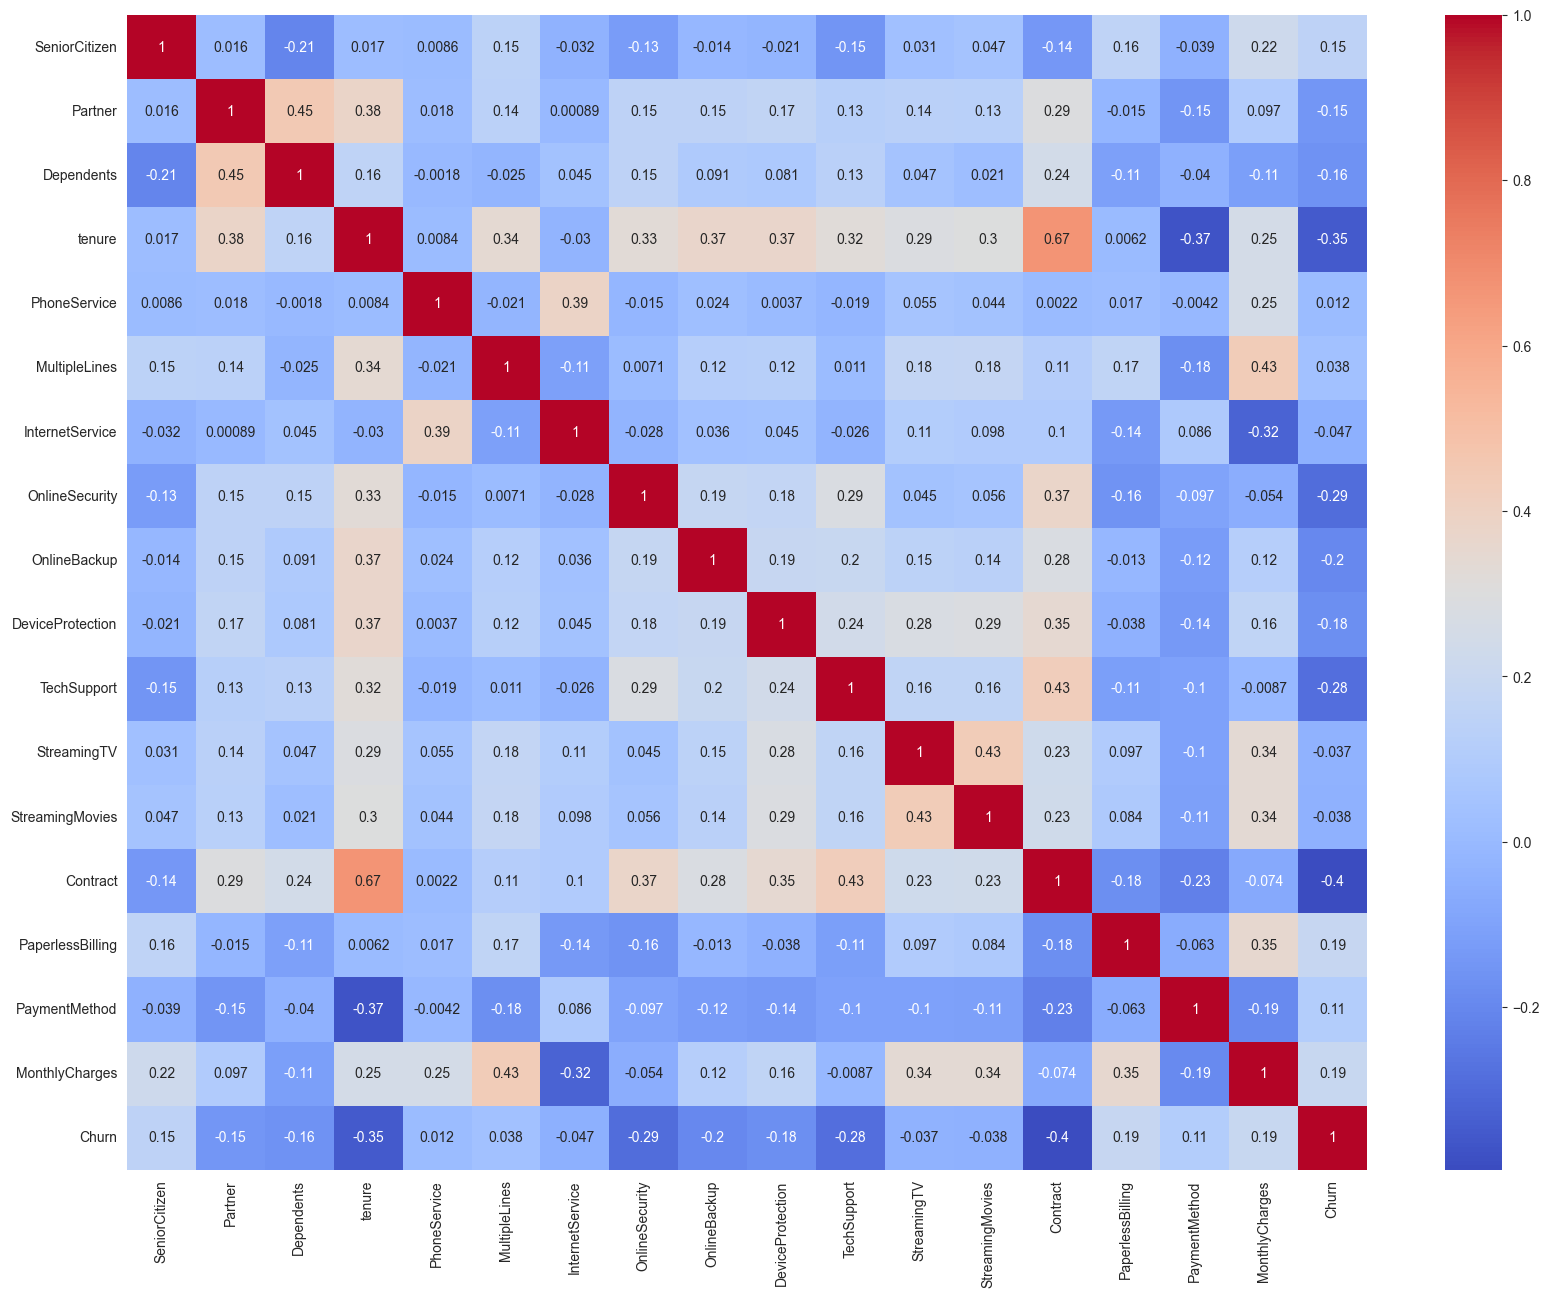

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [6]:
df = df.drop(columns=["Contract", "Churn"])

In [7]:
from sklearn.decomposition import PCA

scaler = PCA(n_components=2)
X = scaler.fit_transform(df)

### Algoritmi partiţionali (KMeans)

Principiul de lucru al KMeans constă în împărțirea datelor în k clustere pe baza distanței minime față de centrele (centroizii) clusterelor. Algoritmul ajustează centrele iterativ până când acestea converg, minimizând suma pătratelor distanțelor dintre puncte și centroizi.

In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

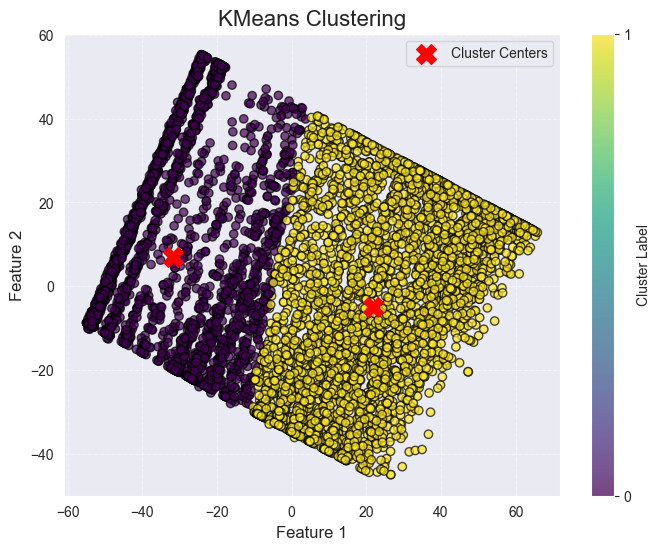

In [9]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolor='k')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Cluster Centers')
plt.title('KMeans Clustering', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
cbar = plt.colorbar(scatter, label='Cluster Label')
cbar.set_ticks(range(kmeans.n_clusters))
plt.legend(loc='upper right', fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels)
print(f"Silhouette Score pentru KMeans: {score:.2f}")

Silhouette Score pentru KMeans: 0.43


### Algoritmi hierarhici (AgglomerativeClustering)

Algoritmul aglomerativ începe prin considerarea fiecărui punct ca un cluster separat, apoi combină succesiv clusterele cele mai apropiate. Procesul continuă până când toate punctele formează un singur cluster sau este atins un număr specificat de clustere.

In [11]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(n_clusters=2)
labels = agg_clustering.fit_predict(X)

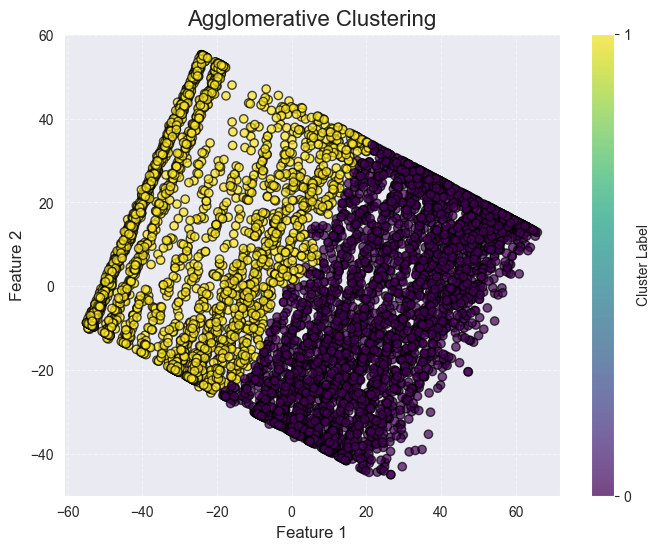

In [12]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolor='k')
plt.title('Agglomerative Clustering', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
cbar = plt.colorbar(scatter, label='Cluster Label')
cbar.set_ticks(range(agg_clustering.n_clusters))
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [13]:
score = silhouette_score(X, labels)
print(f"Silhouette Score pentru AgglomerativeClustering: {score:.2f}")

Silhouette Score pentru AgglomerativeClustering: 0.42


### Algoritmi bazaţi pe densitate (DBSCAN)

DBSCAN identifică clusterele pe baza densității punctelor, grupând punctele apropiate și marcând cele izolate drept zgomot. Algoritmul nu necesită specificarea numărului de clustere, ci depinde de distanța minimă dintre puncte și numărul minim de vecini.

In [14]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=7)
labels = dbscan.fit_predict(X)

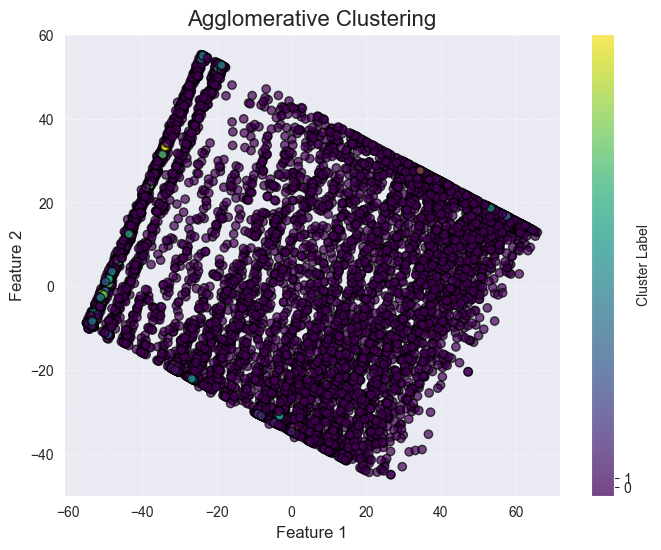

In [15]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolor='k')
plt.title('Agglomerative Clustering', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
cbar = plt.colorbar(scatter, label='Cluster Label')
cbar.set_ticks(range(agg_clustering.n_clusters))
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [16]:
score = silhouette_score(X, labels)
print(f"Silhouette Score pentru DBSCAN: {score:.2f}")

Silhouette Score pentru DBSCAN: -0.48


### Algoritmi bazați pe modele probabiliste (GaussianMixture)

GaussianMixture presupune că datele sunt generate din mai multe distribuții Gaussiane și utilizează metoda Expectation-Maximization (EM) pentru a estima parametrii acestor distribuții. Fiecare punct primește o probabilitate de apartenență la un cluster, iar estimările se ajustează iterativ până la convergență.

In [17]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)
labels = gmm.predict(X)
df["cluster"] = labels

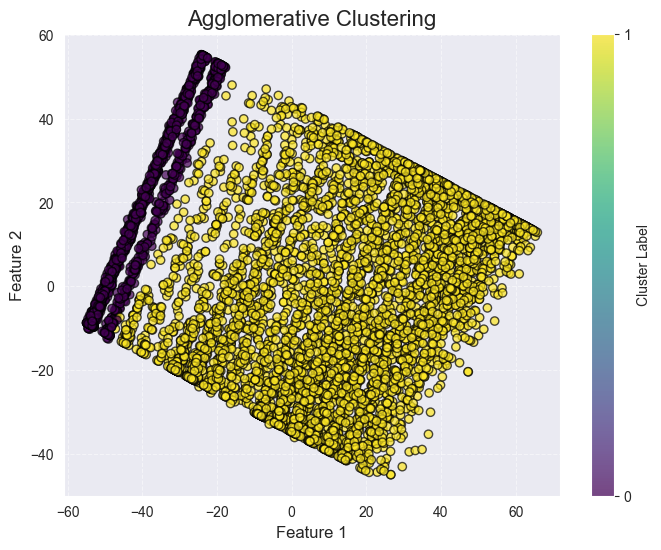

In [18]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolor='k')
plt.title('Agglomerative Clustering', fontsize=16)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
cbar = plt.colorbar(scatter, label='Cluster Label')
cbar.set_ticks(range(agg_clustering.n_clusters))
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

### Concluzie

În acest laborator, am explorat patru tipuri de algoritmi de clusterizare: KMeans, AgglomerativeClustering, DBSCAN și GaussianMixture. Fiecare algoritm a fost aplicat pe seturi de date generate, evidențiind modul în care funcționează în funcție de forma și structura datelor. Am observat că KMeans și GaussianMixture funcționează bine pentru date cu clustere bine separate, în timp ce DBSCAN este mai eficient pentru date cu forme neregulate și poate identifica zgomotul. AgglomerativeClustering a demonstrat o abordare flexibilă pentru datele ierarhice. Evaluarea cu Silhouette Score a confirmat performanța fiecărui algoritm, subliniind importanța alegerii metodei potrivite în funcție de caracteristicile datelor.